In [1]:
%matplotlib widget

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import empymod 
from scipy.constants import mu_0
import pygimli as pg
from pygimli.viewer.mpl import drawModel1D
from sklearn.metrics import root_mean_squared_error
from numpy import linalg as LA
from itertools import product
import plotly.express as px
import pandas as pd
from mpl_toolkits.mplot3d import axes3d
import matplotlib.colors as colors

In [3]:
def FDEM(depth, res, coil_orient=np.array(['H', 'P', 'V']), height=0.15):

    #depth = z.copy()
    #res = 1/sigma_coarse
    #height = 0.15
    #coil_orient=np.array(['H', 'P', 'V'])

    # Define instrument parameters

    Freq = np.logspace(1,5)
    coil_spacing = np.linspace(1,12)
    coil_spacing_p = np.linspace(1,12)

    res_air = 1e6 # air resistivity

    # Define source and receivers geometry

    source = [0, 0, -height]
    receivers = [coil_spacing, np.zeros_like(coil_spacing), -height]
    receivers_p = [coil_spacing_p, np.zeros_like(coil_spacing_p), -height]

    # Define resistivity model
    res = np.hstack((res_air, res)) # include air resistivity

    # Empty array to store store responses
    OUT = []

    # Calculate for horizontal coil orientation
    if any(coil_orient == 'H'):
        # Secondary magnetic field
        H_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        # Primary magnetic field
        H_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                              ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
        op = (H_Hs/H_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (H_Hs/H_Hp).real.amp() * 1e3 # In Phase
        OUT.append([op, ip])

    # Calculate for vertical coil orientation
    if any(coil_orient == 'V'):
        # Secondary magnetic field
        V_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 55, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        # Primary magnetic field
        V_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq, ab = 55, 
                              verb=0)*(2j * np.pi * Freq * mu_0)
        op = (V_Hs/V_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (V_Hs/V_Hp).real.amp() * 1e3 # In Phase
        OUT.append([op, ip])

    # Calculate for perpendicular coil orientation
    if any(coil_orient == 'P'):
        P_Hs = empymod.dipole(source, receivers, depth, res, Freq, ab = 46, xdirect = None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
        P_Hp = empymod.dipole(source, receivers, depth=[], res=[res_air], freqtime= Freq,
                              ab = 66, verb = 0)*(2j * np.pi * Freq * mu_0) 
        op = (P_Hs/P_Hp).imag.amp() * 1e3 # Out of Phase
        ip = (P_Hs/P_Hp).real.amp() * 1e3 # In Phase

        OUT.append([op, ip])

    return np.array(OUT) # [HOP, HIP, VOP, VIP, POP, PIP]

# Sensitivity to first layer boundary 

In [4]:
res_1 = np.logspace(1,2,10)
ratios = np.array([1, 2, 4, 8, 16])
constant_thicks = np.array([16, 32, 64, 128, 256])

models = np.zeros((len(res_1)*len(ratios)*len(constant_thicks),3))

In [5]:
# model conditions
model_conds = np.array(list(product(res_1, ratios, constant_thicks)))

models[:,1] = model_conds[:,0]
models[:,2] = model_conds[:,0] * model_conds[:,1]
models[:,0] = model_conds[:,0] / model_conds[:,2]


In [6]:
factor = 1.05

FreDev_h1 = []

for m in models:
    res1 = m[1:]
    depth1 = [0, m[0]]

    res2 = m[1:]
    depth2 = [0, m[0]*factor]

    data1 = FDEM(depth1, res1)
    data2 = FDEM(depth2, res2)

    FreDev_h1.append(np.abs(data2 - data1)/data1)

In [7]:
FreDev_h1_all = np.sum(np.array(FreDev_h1), axis=0)

Text(0, 0.5, 'Frequency')

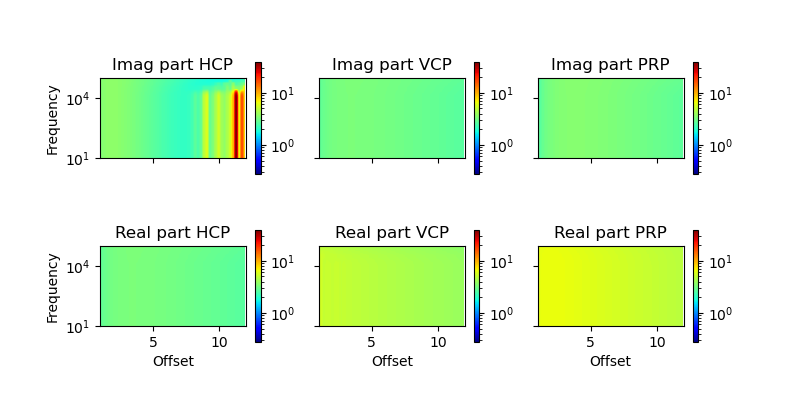

In [8]:
fig, ax = plt.subplots(2,3, figsize=(8,4), sharex=True, sharey=True)

vmin = np.min(FreDev_h1_all)
vmax = np.max(FreDev_h1_all)

Freq = np.logspace(1,5)
coil_spacing = np.linspace(1,12)

c = ax[0,0].imshow(FreDev_h1_all[0,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,0].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,0].set_title('Imag part HCP')
fig.colorbar(c, ax=ax[0,0], shrink=0.8)

c = ax[1,0].imshow(FreDev_h1_all[1,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,0].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,0].set_title('Real part HCP')
fig.colorbar(c, ax=ax[1,0], shrink=0.8)

c = ax[0,1].imshow(FreDev_h1_all[1,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,1].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,1].set_title('Imag part VCP')
fig.colorbar(c, ax=ax[0,1], shrink=0.8)

c = ax[1,1].imshow(FreDev_h1_all[1,1], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,1].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,1].set_title('Real part VCP')
fig.colorbar(c, ax=ax[1,1], shrink=0.8)

c = ax[0,2].imshow(FreDev_h1_all[2,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,2].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,2].set_title('Imag part PRP')
fig.colorbar(c, ax=ax[0,2], shrink=0.8)

c = ax[1,2].imshow(FreDev_h1_all[2,1], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,2].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,2].set_title('Real part PRP')
fig.colorbar(c, ax=ax[1,2], shrink=0.8)

ax[0,0].set_yticks(Freq,)
ax[0,0].set_yscale('log')
#ax[0,0].set_xticks(coil_spacing)
ax[0,0].set_ylim([np.min(Freq), np.max(Freq)])
ax[0,0].set_xlim([np.min(coil_spacing), np.max(coil_spacing)])
ax[1,0].set_xlabel('Offset')
ax[1,1].set_xlabel('Offset')
ax[1,2].set_xlabel('Offset')
ax[0,0].set_ylabel('Frequency')
ax[1,0].set_ylabel('Frequency')

# Sensitivity to first layer resistivity

In [9]:
factor = 1.05

FreDev_s1 = []

for m in models:
    res1 = m[1:]
    depth1 = [0, m[0]]

    res2 = [m[1]*factor, m[2]]
    depth2 = [0, m[0]]

    data1 = FDEM(depth1, res1)
    data2 = FDEM(depth2, res2)

    FreDev_s1.append(np.abs(data2 - data1)/data1)

In [10]:
FreDev_s1_all = np.sum(np.array(FreDev_s1), axis=0)

Text(0, 0.5, 'Frequency')

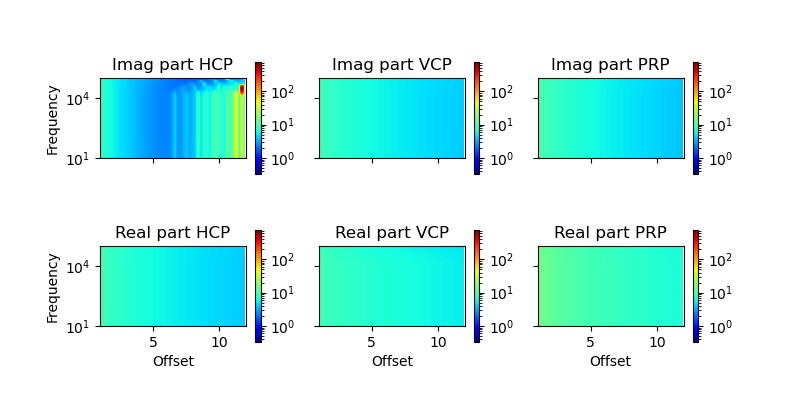

In [11]:
fig, ax = plt.subplots(2,3, figsize=(8,4), sharex=True, sharey=True)

vmin = np.min(FreDev_s1_all)
vmax = np.max(FreDev_s1_all)

Freq = np.logspace(1,5)
coil_spacing = np.linspace(1,12)

c = ax[0,0].imshow(FreDev_s1_all[0,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,0].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,0].set_title('Imag part HCP')
fig.colorbar(c, ax=ax[0,0], shrink=0.8)

c = ax[1,0].imshow(FreDev_s1_all[1,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,0].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,0].set_title('Real part HCP')
fig.colorbar(c, ax=ax[1,0], shrink=0.8)

c = ax[0,1].imshow(FreDev_s1_all[1,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,1].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,1].set_title('Imag part VCP')
fig.colorbar(c, ax=ax[0,1], shrink=0.8)

c = ax[1,1].imshow(FreDev_s1_all[1,1], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,1].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,1].set_title('Real part VCP')
fig.colorbar(c, ax=ax[1,1], shrink=0.8)

c = ax[0,2].imshow(FreDev_s1_all[2,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,2].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,2].set_title('Imag part PRP')
fig.colorbar(c, ax=ax[0,2], shrink=0.8)

c = ax[1,2].imshow(FreDev_s1_all[2,1], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,2].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,2].set_title('Real part PRP')
fig.colorbar(c, ax=ax[1,2], shrink=0.8)

ax[0,0].set_yticks(Freq,)
ax[0,0].set_yscale('log')
#ax[0,0].set_xticks(coil_spacing)
ax[0,0].set_ylim([np.min(Freq), np.max(Freq)])
ax[0,0].set_xlim([np.min(coil_spacing), np.max(coil_spacing)])
ax[1,0].set_xlabel('Offset')
ax[1,1].set_xlabel('Offset')
ax[1,2].set_xlabel('Offset')
ax[0,0].set_ylabel('Frequency')
ax[1,0].set_ylabel('Frequency')

# Sensitivity to second layer resistivity

In [12]:
factor = 1.05

FreDev_s2 = []

for m in models:
    res1 = m[1:]
    depth1 = [0, m[0]]

    res2 = [m[1], m[2]*factor]
    depth2 = [0, m[0]]

    data1 = FDEM(depth1, res1)
    data2 = FDEM(depth2, res2)

    FreDev_s2.append(np.abs(data2 - data1)/data1)

In [15]:
FreDev_s2_all = np.sum(np.array(FreDev_s2), axis=0)

Text(0, 0.5, 'Frequency')

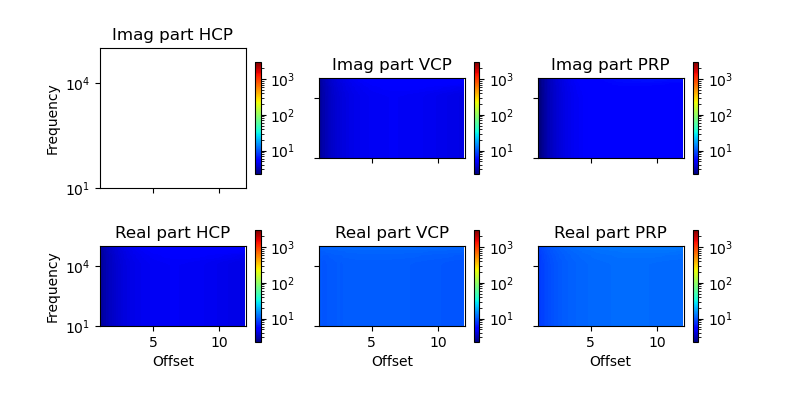

In [20]:
fig, ax = plt.subplots(2,3, figsize=(8,4), sharex=True, sharey=True)

vmin = np.min(FreDev_s2_all)
vmax = np.max(FreDev_s2_all)

Freq = np.logspace(1,5)
coil_spacing = np.linspace(1,12)

c = ax[0,0].imshow(FreDev_s2_all[0,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,0].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,0].set_title('Imag part HCP')
fig.colorbar(c, ax=ax[0,0], shrink=0.8)

c = ax[1,0].imshow(FreDev_s2_all[1,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,0].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,0].set_title('Real part HCP')
fig.colorbar(c, ax=ax[1,0], shrink=0.8)

c = ax[0,1].imshow(FreDev_s2_all[1,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,1].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,1].set_title('Imag part VCP')
fig.colorbar(c, ax=ax[0,1], shrink=0.8)

c = ax[1,1].imshow(FreDev_s2_all[1,1], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,1].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,1].set_title('Real part VCP')
fig.colorbar(c, ax=ax[1,1], shrink=0.8)

c = ax[0,2].imshow(FreDev_s2_all[2,0], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[0,2].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[0,2].set_title('Imag part PRP')
fig.colorbar(c, ax=ax[0,2], shrink=0.8)

c = ax[1,2].imshow(FreDev_s2_all[2,1], cmap='jet', extent=[1, 12, 1, 1e6], aspect=1.5, vmin=vmin, vmax=vmax, norm='log')
#ax[1,2].plot(coil_sp_in_1_coarse, Freq_l, 'w')
ax[1,2].set_title('Real part PRP')
fig.colorbar(c, ax=ax[1,2], shrink=0.8)

ax[0,0].set_yticks(Freq,)
ax[0,0].set_yscale('log')
#ax[0,0].set_xticks(coil_spacing)
ax[0,0].set_ylim([np.min(Freq), np.max(Freq)])
ax[0,0].set_xlim([np.min(coil_spacing), np.max(coil_spacing)])
ax[1,0].set_xlabel('Offset')
ax[1,1].set_xlabel('Offset')
ax[1,2].set_xlabel('Offset')
ax[0,0].set_ylabel('Frequency')
ax[1,0].set_ylabel('Frequency')